# Notebook 01 — Descarga de Datos Externos: NASA POWER (v2)

**Proyecto de Grado — Maestría en Ciencia de Datos**  
**Pontificia Universidad Javeriana Cali — Grupo 8**  
**Autores:** Laura García Salamanca, Daniel Sebastián Rosero Usamá, Juan Villalobos Mora

---

## Correcciones v2
El error **422 Client Error** se debía a que `CLOUD_AMT`, `T2M_MAX` y `T2M_MIN`
**no están disponibles en resolución horaria** para la comunidad RE.
Se corrigen las variables y se agrega `time-standard=UTC`.

## Variables horarias válidas (comunidad RE)

| Variable | Descripción | Unidad |
|---|---|---|
| `ALLSKY_SFC_SW_DWN` | Irradiancia solar total en superficie | W/m² |
| `CLRSKY_SFC_SW_DWN` | Irradiancia cielo despejado | W/m² |
| `T2M` | Temperatura a 2 m | °C |
| `RH2M` | Humedad relativa a 2 m | % |
| `PRECTOTCORR` | Precipitación corregida | mm/h |
| `WS10M` | Velocidad del viento a 10 m | m/s |
| `WD10M` | Dirección del viento a 10 m | grados |
| `PS` | Presión superficial | kPa |
| `SZA` | Ángulo cenital solar | grados |

El índice de claridad `KT = ALLSKY / CLRSKY` se calcula como variable derivada.


---
## Cambios de la revision (septiembre de 2026)

Dos cambios, ninguno de los cuales obliga a volver a descargar.

1. **El indice de claridad ya no se calcula aqui.** Estaba definido en dos
   sitios, este cuaderno y el 02, y con la misma formula defectuosa: asignaba
   cero al indice cuando el denominador tendia a cero, al amanecer y al ocaso.
   Un indice de cero significa cielo cubierto; lo que ocurre alli es que no hay
   denominador. Ahora el indice se define **una sola vez, en el cuaderno 02**,
   con un umbral minimo para el denominador. La columna que este cuaderno
   dejaba en el CSV era ademas ignorada aguas abajo, porque el 02 la
   recalculaba encima.

2. **Se documenta que la consulta es por punto, no interpolada.** El
   documento afirmaba que NASA POWER entrega valores «interpolados al punto de
   coordenadas consultado». No es asi: el servicio devuelve el valor de la
   celda de la grilla que contiene esas coordenadas. La verificacion empirica
   esta en el cuaderno 08.

**No hace falta reejecutar este cuaderno.** El CSV que ya tienes sirve tal
como esta: su columna de indice de claridad la sobrescribe el cuaderno 02.
Solo tendrias que reejecutarlo si quisieras ampliar el periodo o anadir
variables.

---

## 0. Importaciones

In [ ]:
!pip install requests pandas openpyxl tqdm --quiet

import requests
import pandas as pd
import numpy as np
import os, time
from datetime import datetime
from tqdm import tqdm
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
print('Librerias importadas:', datetime.now().strftime('%Y-%m-%d %H:%M:%S'))

Librerias importadas: 2026-09-09 04:01:35


### Estilo unico de figuras

Esta celda fija la **paleta de colores** y los **tamanos de letra** de todas las figuras del cuaderno. Es la misma celda en los once cuadernos, de modo que cualquier figura del trabajo de grado sale con el mismo aspecto.


In [ ]:
# @@ESTILO_TG@@  (marca unica: no editar esta linea)
# =============================================================================
#  ESTILO UNICO DE FIGURAS DEL TRABAJO DE GRADO
#  Esta celda define la paleta y la tipografia de TODAS las figuras.
#  Es identica en los 11 cuadernos: cambiarla aqui cambia solo este cuaderno,
#  por eso si se modifica hay que modificarla en todos.
#
#  Paleta categorica anclada en el azul. Validada con el verificador de
#  accesibilidad de color (separacion OKLab bajo protanopia y deuteranopia,
#  piso de croma, banda de luminosidad y contraste contra fondo blanco):
#  todos los pares de colores pasan, no solo los contiguos.
# =============================================================================
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from cycler import cycler
try:
    import seaborn as sns
except Exception:
    sns = None

# --- 1. Paleta categorica (orden FIJO: la ranura 1 es siempre la serie principal)
C_AZUL    = '#0C60A3'   # ranura 1 - serie principal / observado / T1 / V1
C_AMBAR   = '#D4771A'   # ranura 2 - segunda serie / modelo / T2 / V2
C_CELESTE = '#269AE6'   # ranura 3 - tercera serie / T3 / V3
C_TEJA    = '#963E35'   # ranura 4 - cuarta serie
C_VERDEAZ = '#0D8F73'   # ranura 5 - quinta serie
PALETA_TG = [C_AZUL, C_AMBAR, C_CELESTE, C_TEJA, C_VERDEAZ]

# --- 2. Tonos de apoyo de la rampa azul (rellenos, bandas, sombreados)
C_AZUL_CLARO  = '#81B4EA'
C_AZUL_MEDIO  = '#5A9BDC'
C_AZUL_OSCURO = '#0A3765'

# --- 3. Tinta neutra: texto, ejes, lineas de referencia. NUNCA es una serie.
C_TEXTO      = '#1A1A1A'
C_GRIS       = '#6E6E6E'
C_GRIS_CLARO = '#C9C9C9'

# --- 4. Mapas de color continuos
#   'tg_azul' : secuencial de un solo tono, claro -> oscuro (magnitudes)
#   'tg_div'  : divergente azul <-> teja con gris neutro en el centro
#               (mantiene la lectura de 'RdBu_r': negativo azul, positivo calido)
_SECUENCIAL = ['#F4F9FF', '#D8E8FA', '#B4D2F4', '#81B4EA', '#5A9BDC',
               '#3581C9', '#1667AC', '#0B4E89', '#0A3765']
_DIVERGENTE = ['#0A3765', '#1667AC', '#5A9BDC', '#AFCEEC', '#F2F1EF',
               '#EFC9AC', '#DC9A5A', '#B4642C', '#7E3A2C']
CMAP_SEC = LinearSegmentedColormap.from_list('tg_azul', _SECUENCIAL)
CMAP_DIV = LinearSegmentedColormap.from_list('tg_div',  _DIVERGENTE)

def _registrar_cmap(cm_obj):
    """Registra el mapa por nombre para poder usar cmap='tg_azul'."""
    try:
        mpl.colormaps.register(cm_obj, force=True)          # matplotlib >= 3.6
    except Exception:
        try:
            mpl.cm.register_cmap(cmap=cm_obj)               # matplotlib antiguo
        except Exception:
            pass

for _c in (CMAP_SEC, CMAP_DIV):
    _registrar_cmap(_c)

def escala_azul(n, ini=0.375, fin=1.0):
    """n colores tomados de la rampa azul. Para variables ORDENADAS (anios,
    meses, horizontes): el orden se lee en el tono, de claro a oscuro."""
    if n <= 1:
        return [C_AZUL]
    paso = (fin - ini) / (n - 1)
    return [CMAP_SEC(ini + i * paso) for i in range(n)]

# --- 6. Eje X de fechas legible ----------------------------------------------
import matplotlib.dates as mdates

def eje_fechas(ax):
    """Ajusta el eje X de fechas al rango real de la serie: anios cuando abarca
    anios, meses cuando abarca meses. Evita que se repita la misma etiqueta
    ('2023 2023 2023 ...') cuando el periodo es corto."""
    loc = mdates.AutoDateLocator(minticks=4, maxticks=9)
    ax.xaxis.set_major_locator(loc)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))
    return ax

# --- 7. Trazo por serie: si dos curvas se superponen, el trazo las separa -----
ESTILOS_TG = ['-', '--', ':', '-.', (0, (5, 1, 1, 1))]
TRAZO = {'T1': '-', 'T2': '--', 'T3': ':',
         'V1': '-', 'V2': '--', 'V3': ':'}

# --- 5. Tipografia: tamanos grandes para que la figura se lea en el PDF impreso
TAM_BASE = 13          # texto general dentro de la figura
TAM_EJE  = 14          # etiquetas de los ejes X e Y
TAM_TICK = 12          # numeros de los ejes
TAM_TIT  = 14.5        # titulo del panel
TAM_LEY  = 12          # leyenda

plt.rcParams.update({
    # --- color
    'axes.prop_cycle'   : cycler(color=PALETA_TG),
    'image.cmap'        : 'tg_azul',
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : 'white',
    'savefig.facecolor' : 'white',
    # --- tipografia (lo que pidio la revision: ejes y etiquetas legibles)
    'font.family'       : 'sans-serif',
    'font.size'         : TAM_BASE,
    'axes.titlesize'    : TAM_TIT,
    'axes.labelsize'    : TAM_EJE,
    'axes.titleweight'  : 'bold',
    'axes.labelweight'  : 'normal',
    'xtick.labelsize'   : TAM_TICK,
    'ytick.labelsize'   : TAM_TICK,
    'legend.fontsize'   : TAM_LEY,
    'legend.title_fontsize': TAM_LEY,
    'figure.titlesize'  : TAM_TIT + 1.5,
    # --- trazos y ejes discretos
    'lines.linewidth'   : 1.8,
    'lines.markersize'  : 5.5,
    'axes.linewidth'    : 0.9,
    'axes.edgecolor'    : '#8A8A8A',
    'axes.labelcolor'   : C_TEXTO,
    'text.color'        : C_TEXTO,
    'xtick.color'       : '#8A8A8A',
    'ytick.color'       : '#8A8A8A',
    'xtick.labelcolor'  : C_TEXTO,
    'ytick.labelcolor'  : C_TEXTO,
    'xtick.major.width' : 0.9,
    'ytick.major.width' : 0.9,
    'grid.color'        : C_GRIS_CLARO,
    'grid.linewidth'    : 0.7,
    'grid.alpha'        : 0.55,
    'legend.frameon'    : True,
    'legend.framealpha' : 0.92,
    'legend.edgecolor'  : '#C9C9C9',
    # --- exportacion para Overleaf: el texto viaja como texto dentro del PDF
    'figure.dpi'        : 110,
    'savefig.dpi'       : 300,
    'savefig.bbox'      : 'tight',
    'pdf.fonttype'      : 42,
    'ps.fonttype'       : 42,
    'svg.fonttype'      : 'path',
})

if sns is not None:
    sns.set_palette(PALETA_TG)

print('Estilo de figuras aplicado.')
print(f'  Paleta categorica: {", ".join(PALETA_TG)}')
print(f'  Mapas continuos:   tg_azul (secuencial), tg_div (divergente)')
print(f'  Tamanos: ejes {TAM_EJE} pt, numeros {TAM_TICK} pt, leyenda {TAM_LEY} pt')


Estilo de figuras aplicado.
  Paleta categorica: #0C60A3, #D4771A, #269AE6, #963E35, #0D8F73
  Mapas continuos:   tg_azul (secuencial), tg_div (divergente)
  Tamanos: ejes 14 pt, numeros 12 pt, leyenda 12 pt


## 1. Google Drive

In [ ]:
# @@RUTAS_TG@@  (marca unica: no editar esta linea)
# =============================================================================
#  DONDE VIVE EL PROYECTO
#
#  En el Drive hay mas de una copia del proyecto: la del semestre anterior y la
#  actual. Antes cada cuaderno buscaba un archivo de datos por todo el Drive y
#  se quedaba con el PRIMERO que aparecia, que no siempre era el de la carpeta
#  correcta; por eso 'figuras', 'figuras_PDF' y 'figuras_SVG' se crearon en la
#  carpeta vieja.
#
#  Ahora la carpeta del proyecto se decide UNA sola vez y de forma explicita:
#  es la carpeta cuyo nombre esta en NOMBRE_CARPETA y cuya ruta contiene
#  CARPETA_PROYECTO. TODO lo que el cuaderno escriba va ahi.
#
#  Si algun dia mueves el proyecto (por ejemplo a 'Proyecto Aplicado IV'),
#  cambias UNA linea: CARPETA_PROYECTO. Y la cambias en los once cuadernos.
# =============================================================================
import os
import subprocess

CARPETA_PROYECTO = 'Proyecto Aplicado III'      # <-- la carpeta actual del semestre
NOMBRE_CARPETA   = 'Codigos Trabajo de Grado'   # <-- nombre de la carpeta de codigo
RAIZ_DRIVE       = '/content/drive/MyDrive'

# Rutas que nunca se usan como carpeta del proyecto, aunque coincidan de nombre.
EXCLUIR_RUTAS = ['/anterior/', '/.Trash', '/.shortcut-targets-by-id/',
                 '/copia de ', '/copy of ']


def _montar_drive():
    try:
        from google.colab import drive
    except Exception:
        return
    if not os.path.isdir(RAIZ_DRIVE):
        drive.mount('/content/drive')
    else:
        print('Drive ya montado.')


def _find(patron, tipo='f', maxdepth=None, raiz=RAIZ_DRIVE, timeout=300):
    cmd = ['find', raiz]
    if maxdepth is not None:
        cmd += ['-maxdepth', str(maxdepth)]
    cmd += ['-type', tipo, '-name', patron]
    try:
        res = subprocess.run(cmd, capture_output=True, text=True, timeout=timeout)
    except Exception:
        return []
    return [r for r in res.stdout.strip().split('\n') if r]


def _excluida(ruta):
    r = ruta.lower()
    return any(x.lower() in r for x in EXCLUIR_RUTAS)


def localizar_proyecto():
    """Devuelve la carpeta del proyecto. Falla con un mensaje claro si no la
    encuentra o si encuentra mas de una: nunca elige a ciegas."""
    _montar_drive()

    candidatas = _find(NOMBRE_CARPETA, tipo='d', maxdepth=8)
    if not candidatas:
        candidatas = _find(NOMBRE_CARPETA, tipo='d')
    # Segunda pista: cualquier carpeta que contenga los cuadernos de la cadena.
    for nb in _find('0*_*REVISADO.ipynb', tipo='f', maxdepth=9):
        d = os.path.dirname(nb)
        if d not in candidatas:
            candidatas.append(d)

    validas   = [c for c in candidatas if CARPETA_PROYECTO in c and not _excluida(c)]
    descartes = [c for c in candidatas if c not in validas]

    if len(validas) == 1:
        print(f'Carpeta del proyecto: {validas[0]}')
        if descartes:
            print(f'  ({len(descartes)} carpeta(s) descartada(s) por no estar en '
                  f'"{CARPETA_PROYECTO}")')
        return validas[0]

    print('\n' + '=' * 78)
    print('NO SE PUDO DECIDIR LA CARPETA DEL PROYECTO')
    print('=' * 78)
    print(f'  Se busca:  una carpeta "{NOMBRE_CARPETA}" cuya ruta contenga '
          f'"{CARPETA_PROYECTO}"')
    print(f'  Encontradas: {len(candidatas)}')
    for c in candidatas:
        marca = 'SIRVE     ' if c in validas else 'descartada'
        print(f'    [{marca}] {c}')
    print()
    if not validas:
        print('  Que hacer: comprueba el nombre exacto de la carpeta en Drive y ajusta')
        print('  arriba CARPETA_PROYECTO o NOMBRE_CARPETA. Si moviste el proyecto,')
        print('  recuerda cambiarlo en los once cuadernos.')
    else:
        print('  Hay varias carpetas que sirven. Escribe arriba una CARPETA_PROYECTO')
        print('  mas especifica, por ejemplo la ruta completa desde MyDrive.')
    print('=' * 78 + '\n')
    raise FileNotFoundError(
        f'No hay exactamente una carpeta "{NOMBRE_CARPETA}" bajo "{CARPETA_PROYECTO}".')


# --- La carpeta del proyecto y todo lo que cuelga de ella --------------------
RUTA_BASE     = localizar_proyecto()
RUTA_DATOS    = os.path.join(RUTA_BASE, 'datos')
RUTA_ARRAYS   = os.path.join(RUTA_DATOS, 'arrays')
RUTA_MODELOS  = os.path.join(RUTA_BASE, 'modelos')
RUTA_RES      = os.path.join(RUTA_BASE, 'resultados')
RUTA_FIGS     = os.path.join(RUTA_BASE, 'figuras')       # PNG
RUTA_FIGS_SVG = os.path.join(RUTA_BASE, 'figuras_SVG')   # SVG
RUTA_FIGS_PDF = os.path.join(RUTA_BASE, 'figuras_PDF')   # PDF, el de Overleaf

for _d in (RUTA_DATOS, RUTA_ARRAYS, RUTA_MODELOS, RUTA_RES,
           RUTA_FIGS, RUTA_FIGS_SVG, RUTA_FIGS_PDF):
    os.makedirs(_d, exist_ok=True)


def archivo_de_datos(nombre, obligatorio=True, pista=''):
    """Localiza un archivo de ENTRADA.

    Primero lo busca dentro de la carpeta del proyecto. Solo si no esta lo busca
    en el resto del Drive, y en ese caso avisa en grande: significa que ese
    archivo se quedo en la carpeta vieja y conviene copiarlo.
    Lo que el cuaderno ESCRIBE nunca sale de la carpeta del proyecto.
    """
    for sub in ('datos', os.path.join('datos', 'arrays'), '', 'resultados', 'modelos'):
        cand = os.path.join(RUTA_BASE, sub, nombre) if sub else os.path.join(RUTA_BASE, nombre)
        if os.path.exists(cand):
            return cand

    fuera = _find(nombre, tipo='f')
    if fuera:
        fuera.sort(key=lambda r: os.path.getmtime(r), reverse=True)
        elegido = fuera[0]
        print('\n' + '!' * 78)
        print(f'AVISO: "{nombre}" no esta en la carpeta del {CARPETA_PROYECTO}.')
        print(f'  Se leera de: {elegido}')
        print(f'  Copialo a  : {RUTA_DATOS}')
        print('  Mientras siga en dos sitios, corres el riesgo de leer una version vieja.')
        print('!' * 78 + '\n')
        return elegido

    if obligatorio:
        raise FileNotFoundError(
            f'No se encontro "{nombre}" ni en la carpeta del proyecto ni en el resto '
            f'del Drive.\n  Carpeta del proyecto: {RUTA_BASE}\n  {pista}')
    return None


print(f'  datos      : {RUTA_DATOS}')
print(f'  figuras    : {RUTA_FIGS} (+ _SVG y _PDF)')
print(f'  modelos    : {RUTA_MODELOS}')
print(f'  resultados : {RUTA_RES}')

# --- Entradas propias de este cuaderno ---------------------------------------
# El 00 descarga NASA POWER; el CSV de la estacion solo se usa para comparar.
RUTA_CSV = archivo_de_datos('Datos_2013_2026_completo.csv', obligatorio=False,
                            pista='Es el CSV de la estacion CESMAG.')


Mounted at /content/drive
Carpeta del proyecto: /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado
  datos      : /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/datos
  figuras    : /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/figuras (+ _SVG y _PDF)
  modelos    : /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/modelos
  resultados : /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/resultados


### Figuras en PNG, SVG y PDF

**Añadido en la revisión.** Todas las figuras de este cuaderno se guardan ahora en los tres
formatos, con el mismo nombre y en tres carpetas paralelas: `figuras/` para el PNG,
`figuras_SVG/` para el vectorial editable y `figuras_PDF/` para el que se incluye en Overleaf.

En LaTeX se incluye sin extensión, y así el compilador elige el formato adecuado:

```latex
\includegraphics[width=\linewidth]{figuras_PDF/fig_01b_distribucion}
```

In [ ]:
# --- Guardado de figuras en los tres formatos ----------------------------
#
# El documento se compila en Overleaf, que incluye las figuras en PDF, pero
# conviene tener tambien el SVG (editable) y el PNG (vista rapida y para
# presentaciones). Antes cada cuaderno guardaba en un formato distinto: unos en
# SVG, otros en PDF, otros en PNG. Ahora todos usan esta funcion y producen los
# tres, con el mismo nombre, en tres carpetas paralelas:
#
#   figuras/       nombre.png   300 ppp
#   figuras_SVG/   nombre.svg   vectorial editable
#   figuras_PDF/   nombre.pdf   el que se incluye en LaTeX
#
# En LaTeX basta con \includegraphics{figuras_PDF/nombre} sin extension.
import os
import matplotlib.pyplot as plt

FORMATOS_FIGURA = (
    ('RUTA_FIGS',     'png', {'dpi': 300}),
    ('RUTA_FIGS_SVG', 'svg', {}),
    ('RUTA_FIGS_PDF', 'pdf', {}),
)


def guardar_figura(fig, nombre, verbose=True):
    """Guarda la figura en PNG, SVG y PDF. 'nombre' va SIN extension."""
    if fig is None:
        fig = plt.gcf()
    base = os.path.splitext(os.path.basename(str(nombre)))[0]
    rutas = []
    for var, ext, extra in FORMATOS_FIGURA:
        carpeta = globals().get(var)
        if carpeta is None:
            continue
        os.makedirs(carpeta, exist_ok=True)
        ruta = os.path.join(carpeta, f'{base}.{ext}')
        fig.savefig(ruta, bbox_inches='tight', **extra)
        rutas.append(ruta)
    if verbose:
        print(f'  Figura guardada: {base}.png, .svg y .pdf')
    return rutas


print('Funcion guardar_figura lista: cada figura se guarda en PNG, SVG y PDF.')
for _v in ('RUTA_FIGS', 'RUTA_FIGS_SVG', 'RUTA_FIGS_PDF'):
    print(f'  {_v:<14} {globals().get(_v)}')

Funcion guardar_figura lista: cada figura se guarda en PNG, SVG y PDF.
  RUTA_FIGS      /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/figuras
  RUTA_FIGS_SVG  /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/figuras_SVG
  RUTA_FIGS_PDF  /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/figuras_PDF


## 2. Configuracion de parametros

In [ ]:
LAT = 1.2136
LON = -77.2986

# Variables VALIDAS en resolucion horaria, comunidad RE
# EXCLUIDAS (no disponibles en horario): CLOUD_AMT, T2M_MAX, T2M_MIN
VARIABLES_HORARIAS = [
    'ALLSKY_SFC_SW_DWN',
    'CLRSKY_SFC_SW_DWN',
    'T2M',
    'RH2M',
    'PRECTOTCORR',
    'WS10M',
    'WD10M',
    'PS',
    'SZA',
]

URL_HORARIA = 'https://power.larc.nasa.gov/api/temporal/hourly/point'

print('LAT:', LAT, '| LON:', LON)
print('Variables:', VARIABLES_HORARIAS)

LAT: 1.2136 | LON: -77.2986
Variables: ['ALLSKY_SFC_SW_DWN', 'CLRSKY_SFC_SW_DWN', 'T2M', 'RH2M', 'PRECTOTCORR', 'WS10M', 'WD10M', 'PS', 'SZA']


## 3. DIAGNOSTICO — Verificar API antes de descarga completa
Ejecutar esta celda primero. Si devuelve OK, proceder con la descarga completa.

In [ ]:
params_test = {
    'parameters'   : ','.join(VARIABLES_HORARIAS),
    'community'    : 'RE',
    'longitude'    : LON,
    'latitude'     : LAT,
    'start'        : '20230101',
    'end'          : '20230103',
    'format'       : 'JSON',
    'time-standard': 'UTC'
}

print('Probando API NASA POWER...')
resp = requests.get(URL_HORARIA, params=params_test, timeout=60)
print('HTTP Status:', resp.status_code)

if resp.status_code == 200:
    datos_test = resp.json()['properties']['parameter']
    df_test = pd.DataFrame(datos_test)
    df_test.index = pd.to_datetime(df_test.index, format='%Y%m%d%H')
    print('OK — Registros de prueba:', len(df_test))
    print('Columnas:', list(df_test.columns))
    print(df_test.head(3))
else:
    print('ERROR:', resp.status_code)
    print(resp.text[:600])

Probando API NASA POWER...
HTTP Status: 200
OK — Registros de prueba: 72
Columnas: ['ALLSKY_SFC_SW_DWN', 'CLRSKY_SFC_SW_DWN', 'T2M', 'RH2M', 'PRECTOTCORR', 'WS10M', 'WD10M', 'PS', 'SZA']
                     ALLSKY_SFC_SW_DWN  CLRSKY_SFC_SW_DWN    T2M   RH2M  \
2023-01-01 00:00:00                0.0                0.0  11.81  98.03   
2023-01-01 01:00:00                0.0                0.0  11.55  98.38   
2023-01-01 02:00:00                0.0                0.0  11.33  98.51   

                     PRECTOTCORR  WS10M  WD10M     PS   SZA  
2023-01-01 00:00:00         4.85   1.66  321.6  75.27  90.0  
2023-01-01 01:00:00         4.42   1.73  321.3  75.31  90.0  
2023-01-01 02:00:00         4.65   1.67  319.4  75.32  90.0  


## 4. Funcion de descarga anual

In [ ]:
def descargar_anio(lat, lon, anio, variables, url_base, comunidad='RE', max_reintentos=3):
    """
    Descarga datos horarios NASA POWER para un anio especifico.

    Parametros:
    -----------
    lat, lon       : float -- Coordenadas del punto
    anio           : int   -- Anio a descargar
    variables      : list  -- Variables NASA POWER validas en resolucion horaria
    url_base       : str   -- Endpoint de la API
    comunidad      : str   -- Comunidad de usuario
    max_reintentos : int   -- Reintentos ante fallo de red

    Retorna:
    --------
    pd.DataFrame con indice temporal o None si falla
    """
    inicio = f'{anio}0101'
    fin    = f'{anio}1231'
    if anio == 2013:
        inicio = '20130801'  # Estacion CESMAG inicia agosto 2013
    if anio == 2026:
        fin = '20260430'     # Ultimo mes disponible

    params = {
        'parameters'   : ','.join(variables),
        'community'    : comunidad,
        'longitude'    : lon,
        'latitude'     : lat,
        'start'        : inicio,
        'end'          : fin,
        'format'       : 'JSON',
        'time-standard': 'UTC'
    }

    for intento in range(1, max_reintentos + 1):
        try:
            resp = requests.get(url_base, params=params, timeout=120)
            resp.raise_for_status()
            datos = resp.json()['properties']['parameter']

            df = pd.DataFrame(datos)
            df.index = pd.to_datetime(df.index, format='%Y%m%d%H')
            df.index.name = 'timestamp_utc'
            df.sort_index(inplace=True)
            df.replace(-999,   np.nan, inplace=True)
            df.replace(-999.0, np.nan, inplace=True)

            print(f'  OK {anio}: {len(df):>5} registros  ({inicio} a {fin})')
            return df

        except requests.exceptions.HTTPError as e:
            # Error 422 = parametro invalido, no reintentar
            print(f'  ERROR HTTP {e.response.status_code} en {anio}: {e.response.text[:300]}')
            return None
        except requests.exceptions.Timeout:
            print(f'  TIMEOUT {anio} — intento {intento}/{max_reintentos}. Esperando 30s...')
            time.sleep(30)
        except Exception as e:
            print(f'  FALLO {anio} — intento {intento}/{max_reintentos}: {e}')
            time.sleep(15)

    return None


print('Funcion descargar_anio definida OK')

Funcion descargar_anio definida OK


## 5. Descarga completa 2013 - 2026

In [ ]:
ANIOS = list(range(2013, 2027))

print(f'Iniciando descarga de {len(ANIOS)} anios...')
print('Variables:', VARIABLES_HORARIAS)
print('-' * 55)

datos_por_anio = {}

for anio in tqdm(ANIOS, desc='Descargando'):
    df_anio = descargar_anio(
        lat=LAT, lon=LON,
        anio=anio,
        variables=VARIABLES_HORARIAS,
        url_base=URL_HORARIA
    )
    if df_anio is not None:
        datos_por_anio[anio] = df_anio
    time.sleep(3)

print('-' * 55)
anios_ok     = list(datos_por_anio.keys())
anios_fallo  = [a for a in ANIOS if a not in datos_por_anio]
print(f'Exitosos : {anios_ok}')
print(f'Fallidos : {anios_fallo}')

Iniciando descarga de 14 anios...
Variables: ['ALLSKY_SFC_SW_DWN', 'CLRSKY_SFC_SW_DWN', 'T2M', 'RH2M', 'PRECTOTCORR', 'WS10M', 'WD10M', 'PS', 'SZA']
-------------------------------------------------------


Descargando:   0%|          | 0/14 [00:00<?, ?it/s]

  OK 2013:  3672 registros  (20130801 a 20131231)


Descargando:   7%|▋         | 1/14 [00:04<00:59,  4.61s/it]

  OK 2014:  8760 registros  (20140101 a 20141231)


...

  OK 2025:  8760 registros  (20250101 a 20251231)


Descargando:  93%|█████████▎| 13/14 [00:55<00:04,  4.23s/it]

  OK 2026:  2880 registros  (20260101 a 20260430)


Descargando: 100%|██████████| 14/14 [00:59<00:00,  4.28s/it]

-------------------------------------------------------
Exitosos : [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
Fallidos : []


## 6. Consolidacion y variables derivadas

In [ ]:
if not datos_por_anio:
    raise RuntimeError('Sin datos descargados. Revisar celda de diagnostico.')

df_nasa = pd.concat(list(datos_por_anio.values()), axis=0)
df_nasa.sort_index(inplace=True)

n_dup = df_nasa.index.duplicated().sum()
if n_dup > 0:
    print(f'Eliminando {n_dup} timestamps duplicados')
    df_nasa = df_nasa[~df_nasa.index.duplicated(keep='first')]

# --- El indice de claridad se calcula en el cuaderno 02 — PARCHE DE LA REVISION
#
# Aqui se calculaba KT = ALLSKY / CLRSKY asignando cero cuando el denominador
# valia cero. Al amanecer y al ocaso el denominador tiende a cero, y un indice
# de cero significa "cielo totalmente cubierto", no "no hay denominador": esos
# ceros falsos inflaban la categoria de cielo cubierto.
#
# El indice se define ahora una sola vez, en el cuaderno 02, con un umbral
# minimo de 20 W/m2 para el denominador y relleno dentro del mismo dia. Se
# retira de aqui para que no existan dos definiciones de la misma variable.
# El cuaderno 02 lo recalculaba encima de todos modos, asi que ningun
# resultado publicado dependia de esta columna.

print('Dataset NASA POWER consolidado:')
print(f'  Registros : {len(df_nasa):,}')
print(f'  Periodo   : {df_nasa.index.min()} a {df_nasa.index.max()}')
print(f'  Variables : {list(df_nasa.columns)}')
print()
print('  El indice de claridad se calcula en el cuaderno 02.')
print()
miss = df_nasa.isnull().sum()
pct  = (miss / len(df_nasa) * 100).round(2)
print(pd.DataFrame({'Faltantes': miss, 'Porcentaje': pct}).to_string())
print()
print(df_nasa.describe().round(2).to_string())

Dataset NASA POWER consolidado:
  Registros : 111,744
  Periodo   : 2013-08-01 00:00:00 a 2026-04-30 23:00:00
  Variables : ['ALLSKY_SFC_SW_DWN', 'CLRSKY_SFC_SW_DWN', 'T2M', 'RH2M', 'PRECTOTCORR', 'WS10M', 'WD10M', 'PS', 'SZA']

  El indice de claridad se calcula en el cuaderno 02.

                   Faltantes  Porcentaje
ALLSKY_SFC_SW_DWN          0         0.0
CLRSKY_SFC_SW_DWN          0         0.0
T2M                        0         0.0
RH2M                       0         0.0
PRECTOTCORR                0         0.0
WS10M                      0         0.0
WD10M                      0         0.0
PS                         0         0.0
SZA                        0         0.0

       ALLSKY_SFC_SW_DWN  CLRSKY_SFC_SW_DWN        T2M       RH2M  PRECTOTCORR      WS10M      WD10M         PS        SZA
count          111744.00          111744.00  111744.00  111744.00    111744.00  111744.00  111744.00  111744.00  111744.00
mean              170.50             290.17      13.29     

## 7. Guardado en Google Drive

In [ ]:
ruta_csv = os.path.join(RUTA_DATOS, 'nasa_power_pasto_2013_2026_horario.csv')
df_nasa.to_csv(ruta_csv)

tam_mb = os.path.getsize(ruta_csv) / 1024 / 1024
print(f'Guardado: {ruta_csv}')
print(f'Tamano  : {tam_mb:.2f} MB')

Guardado: /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/datos/nasa_power_pasto_2013_2026_horario.csv
Tamano  : 7.38 MB


## 8. Verificacion visual

  Figura guardada: fig_00_nasa_power_verificacion.png, .svg y .pdf


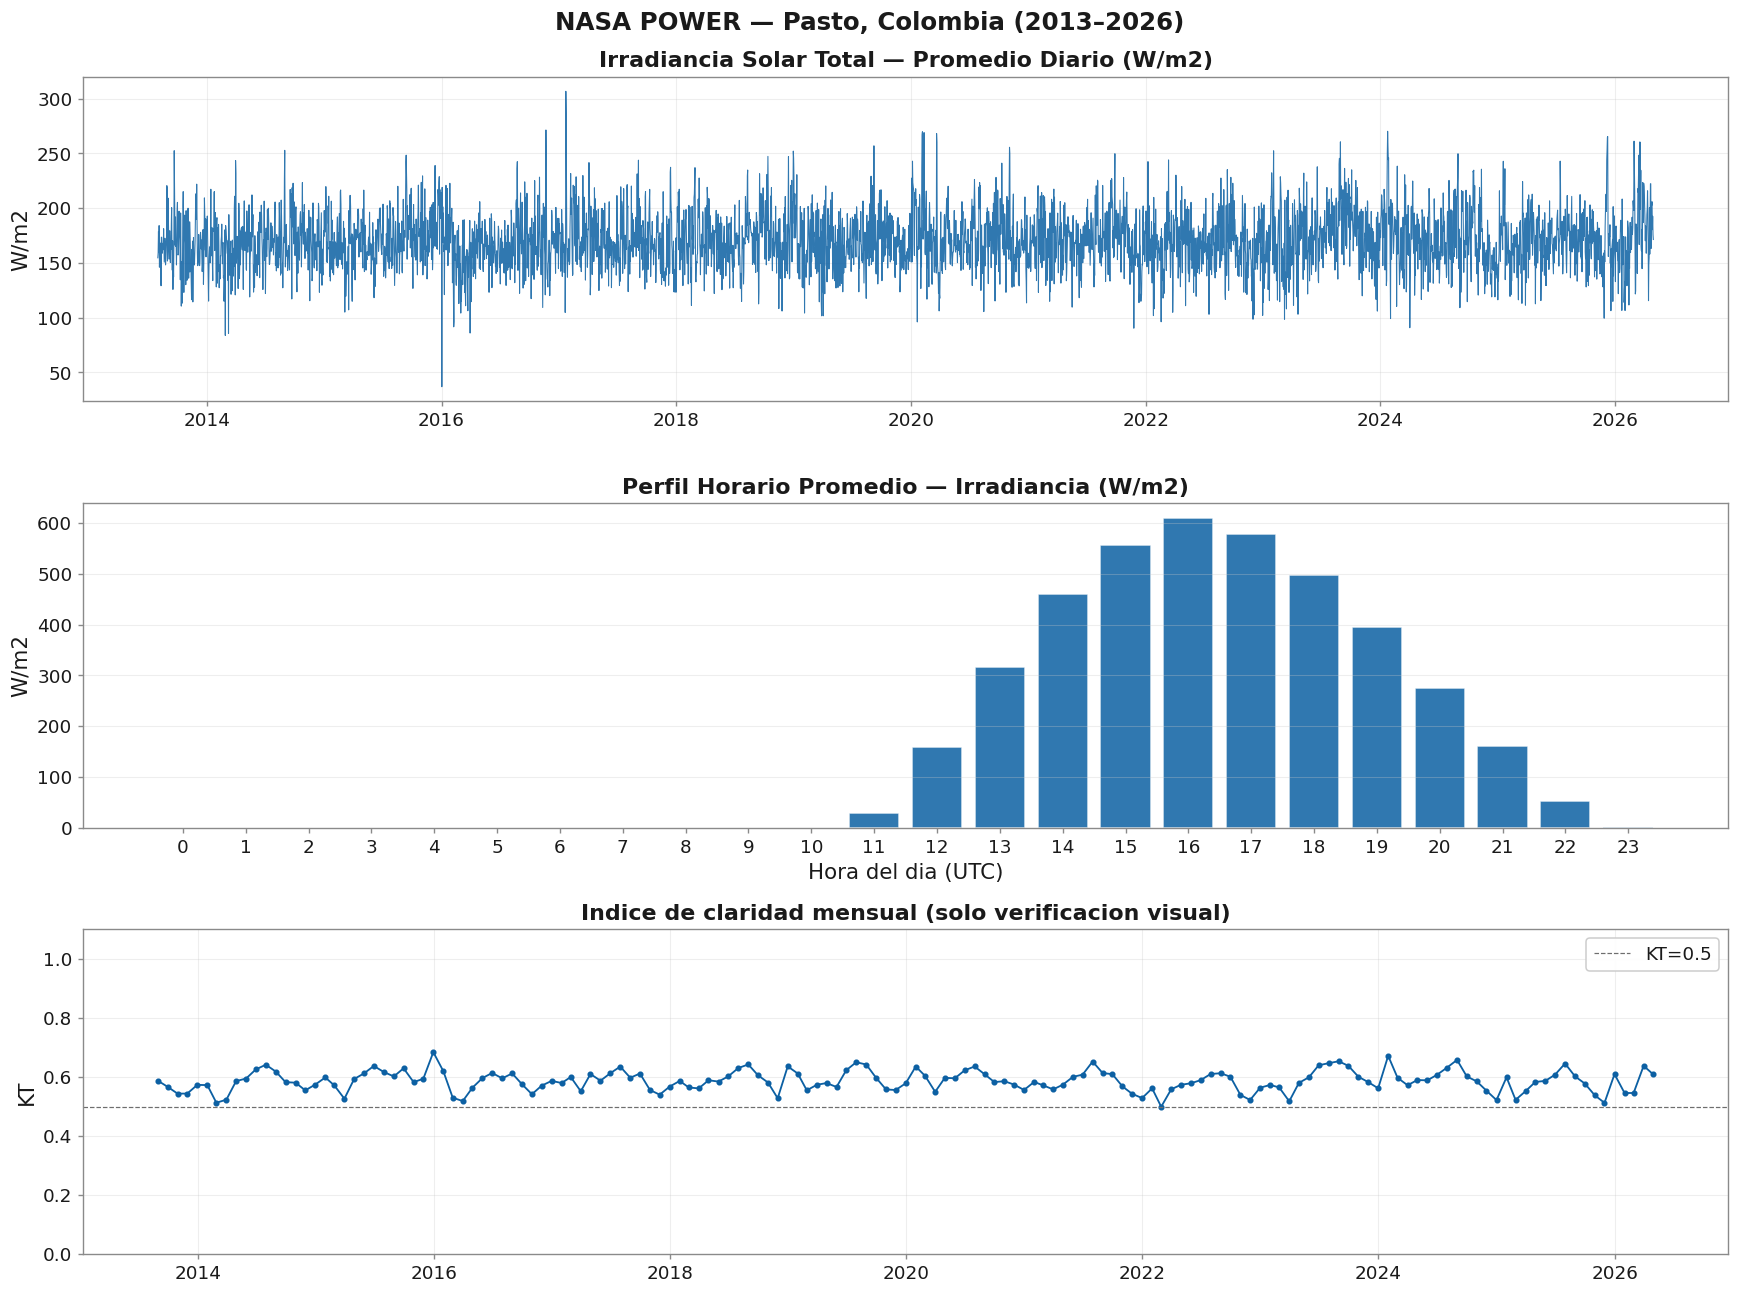

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12))
fig.suptitle('NASA POWER — Pasto, Colombia (2013–2026)', fontsize=16, fontweight='bold')

# Panel 1: Serie de irradiancia diaria
irr_dia = df_nasa['ALLSKY_SFC_SW_DWN'].resample('D').mean()
axes[0].plot(irr_dia.index, irr_dia.values, color=C_AZUL, lw=0.7, alpha=0.85)
axes[0].set_title('Irradiancia Solar Total — Promedio Diario (W/m2)')
axes[0].set_ylabel('W/m2')
axes[0].grid(True, alpha=0.3)

# Panel 2: Perfil horario promedio
perfil = df_nasa['ALLSKY_SFC_SW_DWN'].groupby(df_nasa.index.hour).mean()
axes[1].bar(perfil.index, perfil.values, color=C_AZUL, alpha=0.85, edgecolor='white')
axes[1].set_title('Perfil Horario Promedio — Irradiancia (W/m2)')
axes[1].set_ylabel('W/m2')
axes[1].set_xlabel('Hora del dia (UTC)')
axes[1].set_xticks(range(0, 24))
axes[1].grid(True, alpha=0.3, axis='y')

# Panel 3: indice de claridad mensual
#
# PARCHE DE LA REVISION. Este cuaderno ya no guarda la columna del indice: se
# calcula una sola vez, en el cuaderno 02. Para esta figura de verificacion se
# reconstruye al vuelo con la MISMA regla del 02 —minimo de 20 W/m2 en el
# denominador— y no se guarda en ningun sitio. Sirve solo para comprobar a
# simple vista que la descarga tiene sentido.
UMBRAL_CLR = 20.0
_kt = np.where(df_nasa['CLRSKY_SFC_SW_DWN'] > UMBRAL_CLR,
               (df_nasa['ALLSKY_SFC_SW_DWN'] /
                df_nasa['CLRSKY_SFC_SW_DWN']).clip(0, 1.5),
               np.nan)
kt_mes = pd.Series(_kt, index=df_nasa.index).resample('ME').mean()
axes[2].plot(kt_mes.index, kt_mes.values, color=C_AZUL, lw=1.2, marker='o', ms=3)
axes[2].axhline(y=0.5, color=C_GRIS, linestyle='--', lw=0.8, label='KT=0.5')
axes[2].set_title('Indice de claridad mensual (solo verificacion visual)')
axes[2].set_ylabel('KT')
axes[2].set_ylim(0, 1.1)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
guardar_figura(fig, 'fig_00_nasa_power_verificacion')
plt.show()

## 9. Verificacion de cobertura temporal

In [ ]:
idx_esperado  = pd.date_range(start=df_nasa.index.min(), end=df_nasa.index.max(), freq='h')
ts_ausentes   = idx_esperado.difference(df_nasa.index)

print('COBERTURA TEMPORAL')
print(f'  Esperados   : {len(idx_esperado):,}')
print(f'  Descargados : {len(df_nasa):,}')
print(f'  Ausentes    : {len(ts_ausentes):,}')

if len(ts_ausentes) == 0:
    print('  OK — Cobertura temporal completa')
else:
    print('  Primeros ausentes:', ts_ausentes[:5].tolist())

print()
print('Notebook 00 completado. Siguiente: 01_eda_estacion_cesmag.ipynb')

COBERTURA TEMPORAL
  Esperados   : 111,744
  Descargados : 111,744
  Ausentes    : 0
  OK — Cobertura temporal completa

Notebook 00 completado. Siguiente: 01_eda_estacion_cesmag.ipynb


## Nota sobre la naturaleza espacial de la consulta

El extremo utilizado es `api/temporal/hourly/point`. La palabra *point* nombra
la forma de la consulta —se pide por un par de coordenadas—, no la resolucion
del dato: el servicio devuelve la serie de la **celda de la grilla que contiene
esas coordenadas**, sin interpolar al punto exacto. Las coordenadas del
proyecto, 1.2136 N y 77.2986 O, caen dentro de una celda cuyo valor se comparte
con todo el territorio que esa celda cubre.

Esto importa por dos razones y las dos van al documento:

- La afirmacion de que los valores estan «interpolados al punto de coordenadas
  consultado» es incorrecta y hay que corregirla en la seccion de datos.
- La resolucion efectiva de las variables satelitales, del orden de un grado
  para los productos de irradiancia, es una limitacion real del trabajo y
  conviene declararla como tal en lugar de que la encuentre el jurado.

La verificacion empirica —descargar las celdas vecinas y comprobar que
comparten valores— esta en el **cuaderno 08**, que es el que produce los mapas
de grillas para el documento.

In [ ]:
# --- Verificacion puntual de unidades de PRECTOTCORR ------------------------
# Comprobacion de una sola vez, conservada como registro: el valor diario que
# entrega la API coincide con la SUMA de los valores horarios, no con su media.
# Es decir, la variable esta en milimetros acumulados en el periodo, no en una
# tasa media. Si esta comprobacion no se documenta, la unidad de la variable en
# la tabla de datos del documento queda sin respaldo.
import requests, pandas as pd

base = {'parameters':'PRECTOTCORR', 'community':'RE',
        'longitude':-77.2986, 'latitude':1.2136,
        'start':'20230101', 'end':'20230107', 'format':'JSON'}

d = requests.get('https://power.larc.nasa.gov/api/temporal/daily/point',
                 params=base, timeout=60).json()
diario = pd.Series(d['properties']['parameter']['PRECTOTCORR'])

h = requests.get('https://power.larc.nasa.gov/api/temporal/hourly/point',
                 params={**base, 'time-standard':'UTC'}, timeout=60).json()
hor = pd.Series(h['properties']['parameter']['PRECTOTCORR'])
hor.index = pd.to_datetime(hor.index, format='%Y%m%d%H')

# PARCHE DE LA REVISION: las tres series se alinean por FECHA, no por posicion.
# Antes se comparaban con .values, que exige que las tres tengan exactamente la
# misma longitud; si la API devuelve un dia de mas o de menos en alguno de los
# dos extremos, la celda se caia con 'All arrays must be of the same length'.
diario.index = pd.to_datetime(diario.index, format='%Y%m%d')
comp = pd.DataFrame({
    'diario_API': pd.to_numeric(diario, errors='coerce'),
    'suma_24h'  : hor.resample('D').sum(),
    'media_24h' : hor.resample('D').mean(),
}).dropna()

print(comp.round(4).to_string())
print()
dif_suma  = (comp['diario_API'] - comp['suma_24h']).abs().mean()
dif_media = (comp['diario_API'] - comp['media_24h']).abs().mean()
print(f'Diferencia media frente a la suma  : {dif_suma:.4f}')
print(f'Diferencia media frente a la media : {dif_media:.4f}')
print()
if dif_suma < dif_media:
    print('El valor diario coincide con la SUMA de las horarias:')
    print('la variable esta en milimetros acumulados en el periodo.')
else:
    print('El valor diario coincide con la MEDIA de las horarias:')
    print('la variable esta expresada como tasa media.')

            diario_API  suma_24h  media_24h
2023-01-01        9.10    162.73     6.7804
2023-01-02        4.20    174.27     7.2612
2023-01-03        2.51     50.50     2.1042
2023-01-04        1.84     45.11     1.8796
2023-01-05        2.13     54.15     2.2562
2023-01-06        4.96     69.59     2.8996
2023-01-07        5.83    182.53     7.6054

Diferencia media frente a la suma  : 101.1871
Diferencia media frente a la media : 1.3983

El valor diario coincide con la MEDIA de las horarias:
la variable esta expresada como tasa media.
